# **helmet detection**

In [37]:
!pip install ultralytics -q

import os
from ultralytics import YOLO
from IPython.display import Image as IPImage
from google.colab import files
import glob

# ✅ Clone repo that has best.pt already inside
!git clone https://github.com/Viddesh1/Bike-Helmet-Detectionv2.git
print("Files:", os.listdir("Bike-Helmet-Detectionv2/weights"))

# ✅ Load the ready-made bike helmet model
model = YOLO("Bike-Helmet-Detectionv2/weights/best.pt")
print("✅ Loaded! Classes:", model.names)


fatal: destination path 'Bike-Helmet-Detectionv2' already exists and is not an empty directory.
Files: ['information.txt', 'best.pt', 'last.pt']
✅ Loaded! Classes: {0: 'Bike_Rider', 1: 'Helmet', 2: 'No_Helmet'}


🗑️ Cleared old results


Saving dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpeg to dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpeg
Running detection on: dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpeg

image 1/1 /content/dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpeg: 384x640 2 Bike_Riders, 40.3ms
Speed: 2.5ms preprocess, 40.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/helmet_test
Output file: /content/runs/detect/helmet_test/dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpg


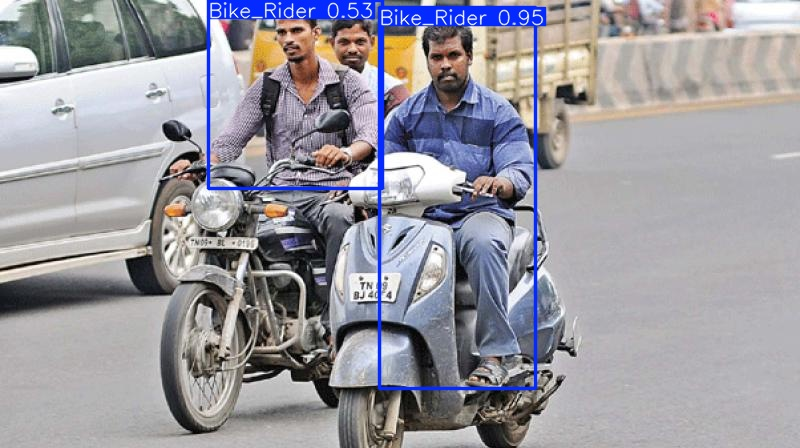

In [43]:
import shutil, os, glob
from ultralytics import YOLO
from IPython.display import Image as IPImage
from google.colab import files

# ✅ Load model
model = YOLO("Bike-Helmet-Detectionv2/weights/best.pt")

# ✅ Delete ALL previous results first
if os.path.exists("/content/runs"):
    shutil.rmtree("/content/runs")
    print("🗑️ Cleared old results")

# ✅ Upload new image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Running detection on:", img_path)

# ✅ Detect
model.predict(source=img_path, conf=0.4, save=True, name="helmet_test")

# ✅ Show result
output = sorted(glob.glob("/content/runs/detect/**/*.*", recursive=True))
output = [f for f in output if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]
print("Output file:", output[-1])
IPImage(output[-1], width=700)

In [20]:
import ultralytics
print(ultralytics.__version__)

8.4.53


# **GUI**

In [39]:
!pip install streamlit ultralytics opencv-python-headless pillow -q
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
changed 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [54]:
%%writefile app.py

import streamlit as st
import cv2
import numpy as np
import shutil
import os
from ultralytics import YOLO
from PIL import Image

st.set_page_config(
    page_title = "Traffic Helmet Detection",
    page_icon  = "🪖",
    layout     = "wide"
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Orbitron:wght@700;900&family=Exo+2:wght@300;400;500;600&display=swap');

html, body, [class*="css"] {
    font-family: 'Exo 2', sans-serif;
}

.stApp {
    background: #020412;
    min-height: 100vh;
    overflow-x: hidden;
}

.stApp::before {
    content: '';
    position: fixed;
    top: 0; left: 0;
    width: 100%; height: 100%;
    background:
        radial-gradient(ellipse at 20% 20%, rgba(0,242,254,0.07) 0%, transparent 50%),
        radial-gradient(ellipse at 80% 80%, rgba(79,172,254,0.07) 0%, transparent 50%),
        radial-gradient(ellipse at 50% 50%, rgba(120,80,255,0.05) 0%, transparent 70%);
    pointer-events: none;
    z-index: 0;
}

.main-title {
    text-align: center;
    font-family: 'Orbitron', monospace;
    font-size: 2.8rem;
    font-weight: 900;
    background: linear-gradient(90deg, #00f2fe, #4facfe, #a78bfa, #00f2fe);
    background-size: 300% auto;
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    animation: shimmer 4s linear infinite;
    margin: 0;
    padding-top: 1.5rem;
    letter-spacing: 3px;
    text-transform: uppercase;
}

@keyframes shimmer {
    0%   { background-position: 0% center; }
    100% { background-position: 300% center; }
}

.subtitle {
    text-align: center;
    color: #4a5568;
    font-size: 0.9rem;
    margin-top: 0.5rem;
    margin-bottom: 0.5rem;
    letter-spacing: 2px;
    text-transform: uppercase;
    font-weight: 300;
}

.divider {
    text-align: center;
    color: #4facfe;
    font-size: 1.2rem;
    margin: 0.5rem 0 2rem 0;
    opacity: 0.6;
    letter-spacing: 8px;
}

.cyber-card {
    background: linear-gradient(135deg, rgba(255,255,255,0.03) 0%, rgba(79,172,254,0.05) 100%);
    border: 1px solid rgba(79,172,254,0.2);
    border-radius: 16px;
    padding: 1.5rem;
    position: relative;
    overflow: hidden;
    transition: border-color 0.3s ease;
}

.cyber-card::before {
    content: '';
    position: absolute;
    top: 0; left: 0;
    width: 100%; height: 2px;
    background: linear-gradient(90deg, transparent, #4facfe, #00f2fe, transparent);
    animation: scan-line 3s linear infinite;
}

@keyframes scan-line {
    0%   { transform: translateX(-100%); }
    100% { transform: translateX(100%); }
}

.section-label {
    font-family: 'Orbitron', monospace;
    font-size: 0.75rem;
    color: #4facfe;
    letter-spacing: 3px;
    text-transform: uppercase;
    margin-bottom: 1rem;
    display: flex;
    align-items: center;
    gap: 8px;
}

.section-label::after {
    content: '';
    flex: 1;
    height: 1px;
    background: linear-gradient(90deg, rgba(79,172,254,0.4), transparent);
}

.stat-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 12px;
    margin-top: 1.5rem;
}

.stat-card {
    background: rgba(255,255,255,0.03);
    border: 1px solid rgba(255,255,255,0.08);
    border-radius: 12px;
    padding: 1rem 0.5rem;
    text-align: center;
    position: relative;
    overflow: hidden;
    animation: fadeInUp 0.5s ease forwards;
}

.stat-card::after {
    content: '';
    position: absolute;
    bottom: 0; left: 0;
    width: 100%; height: 2px;
}

.stat-card.total::after   { background: #63b3ed; }
.stat-card.helmet::after  { background: #48bb78; }
.stat-card.danger::after  { background: #fc8181; }
.stat-card.rider::after   { background: #f6ad55; }

@keyframes fadeInUp {
    from { opacity: 0; transform: translateY(16px); }
    to   { opacity: 1; transform: translateY(0); }
}

.stat-number {
    font-family: 'Orbitron', monospace;
    font-size: 2.2rem;
    font-weight: 900;
    margin: 0;
    line-height: 1;
}

.stat-label {
    font-size: 0.7rem;
    color: #718096;
    margin: 6px 0 0;
    letter-spacing: 2px;
    text-transform: uppercase;
}

.total-num   { color: #63b3ed; }
.helmet-num  { color: #48bb78; }
.danger-num  { color: #fc8181; }
.rider-num   { color: #f6ad55; }

.verdict-safe {
    background: linear-gradient(135deg, rgba(72,187,120,0.15), rgba(72,187,120,0.05));
    border: 1px solid rgba(72,187,120,0.4);
    border-radius: 12px;
    padding: 1rem 1.5rem;
    color: #68d391;
    font-family: 'Orbitron', monospace;
    font-size: 0.85rem;
    letter-spacing: 2px;
    text-align: center;
    animation: pulse-green 2s ease infinite;
    margin-top: 1rem;
}

.verdict-danger {
    background: linear-gradient(135deg, rgba(252,129,129,0.15), rgba(252,129,129,0.05));
    border: 1px solid rgba(252,129,129,0.4);
    border-radius: 12px;
    padding: 1rem 1.5rem;
    color: #fc8181;
    font-family: 'Orbitron', monospace;
    font-size: 0.85rem;
    letter-spacing: 2px;
    text-align: center;
    animation: pulse-red 2s ease infinite;
    margin-top: 1rem;
}

@keyframes pulse-green {
    0%, 100% { box-shadow: 0 0 0 rgba(72,187,120,0); }
    50%       { box-shadow: 0 0 20px rgba(72,187,120,0.3); }
}

@keyframes pulse-red {
    0%, 100% { box-shadow: 0 0 0 rgba(252,129,129,0); }
    50%       { box-shadow: 0 0 20px rgba(252,129,129,0.3); }
}

.empty-state {
    text-align: center;
    padding: 4rem 2rem;
    color: #2d3748;
}

.empty-icon {
    font-size: 4rem;
    animation: float 3s ease-in-out infinite;
    display: block;
    margin-bottom: 1rem;
}

@keyframes float {
    0%, 100% { transform: translateY(0); }
    50%       { transform: translateY(-12px); }
}

.empty-title {
    font-family: 'Orbitron', monospace;
    font-size: 1rem;
    color: #4a5568;
    letter-spacing: 2px;
    margin: 0;
}

div[data-testid="stImage"] img {
    border-radius: 12px;
    border: 1px solid rgba(79,172,254,0.2);
    width: 100%;
    transition: border-color 0.3s ease;
}

div[data-testid="stImage"] img:hover {
    border-color: rgba(79,172,254,0.5);
}

.stButton > button {
    background: linear-gradient(90deg, #00f2fe, #4facfe, #a78bfa) !important;
    background-size: 200% auto !important;
    color: #020412 !important;
    font-family: 'Orbitron', monospace !important;
    font-weight: 700 !important;
    font-size: 0.95rem !important;
    letter-spacing: 3px !important;
    text-transform: uppercase !important;
    border: none !important;
    border-radius: 10px !important;
    padding: 0.75rem 2rem !important;
    width: 100% !important;
    transition: all 0.4s ease !important;
    animation: btn-glow 2s ease infinite !important;
}

@keyframes btn-glow {
    0%, 100% { box-shadow: 0 0 10px rgba(0,242,254,0.3); }
    50%       { box-shadow: 0 0 25px rgba(79,172,254,0.6); }
}

.stButton > button:hover {
    background-position: right center !important;
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 30px rgba(79,172,254,0.5) !important;
}

[data-testid="stSidebar"] {
    background: rgba(2,4,18,0.95) !important;
    border-right: 1px solid rgba(79,172,254,0.15) !important;
}

[data-testid="stSidebar"] .stButton > button {
    background: rgba(79,172,254,0.08) !important;
    color: #63b3ed !important;
    border: 1px solid rgba(79,172,254,0.2) !important;
    font-family: 'Exo 2', sans-serif !important;
    font-size: 0.85rem !important;
    letter-spacing: 1px !important;
    animation: none !important;
    box-shadow: none !important;
}

[data-testid="stSidebar"] .stButton > button:hover {
    background: rgba(79,172,254,0.15) !important;
    border-color: rgba(79,172,254,0.4) !important;
    box-shadow: none !important;
}

.sidebar-logo {
    font-family: 'Orbitron', monospace;
    font-size: 1.1rem;
    font-weight: 700;
    color: #4facfe;
    letter-spacing: 2px;
    text-align: center;
    padding: 1rem 0 0.5rem;
}

.sidebar-section {
    font-family: 'Orbitron', monospace;
    font-size: 0.65rem;
    color: #4facfe;
    letter-spacing: 3px;
    text-transform: uppercase;
    margin: 1.5rem 0 0.75rem;
    opacity: 0.8;
}

.legend-item {
    display: flex;
    align-items: center;
    gap: 10px;
    font-size: 0.82rem;
    color: #718096;
    margin: 6px 0;
}

.legend-dot {
    width: 10px; height: 10px;
    border-radius: 50%;
    flex-shrink: 0;
}

.upload-zone {
    border: 2px dashed rgba(79,172,254,0.25);
    border-radius: 16px;
    padding: 3rem 2rem;
    text-align: center;
    animation: border-pulse 3s ease infinite;
}

@keyframes border-pulse {
    0%, 100% { border-color: rgba(79,172,254,0.25); }
    50%       { border-color: rgba(79,172,254,0.55); }
}

.upload-icon {
    font-size: 3rem;
    display: block;
    margin-bottom: 0.75rem;
    animation: float 3s ease-in-out infinite;
}

.upload-text {
    font-family: 'Orbitron', monospace;
    font-size: 0.85rem;
    color: #4a5568;
    letter-spacing: 2px;
}

div[data-testid="stFileUploader"] {
    background: rgba(79,172,254,0.03) !important;
    border: 1px solid rgba(79,172,254,0.15) !important;
    border-radius: 12px !important;
    padding: 0.5rem !important;
}

.stSpinner > div {
    border-top-color: #4facfe !important;
}
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_model():
    return YOLO("Bike-Helmet-Detectionv2/weights/best.pt")

model = load_model()

COLORS = {
    "helmet":     (34,  197, 94),
    "head":       (239, 68,  68),
    "no helmet":  (239, 68,  68),
    "bike rider": (251, 146, 60),
    "rider":      (251, 146, 60),
}

def run_detection(pil_image, conf_thresh):
    img_bgr = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    results  = model.predict(img_bgr, conf=conf_thresh, verbose=False)
    counts   = {}

    for box in results[0].boxes:
        cls_id = int(box.cls)
        label  = model.names[cls_id].lower()
        counts[label] = counts.get(label, 0) + 1
        conf   = float(box.conf)
        color  = COLORS.get(label, (255, 255, 0))
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 3)
        text = f"{label.upper()}  {conf:.0%}"
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        cv2.rectangle(img_bgr, (x1, y1-th-12), (x1+tw+10, y1), color, -1)
        cv2.putText(img_bgr, text, (x1+5, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)

    return Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)), counts

with st.sidebar:
    st.markdown('<div class="sidebar-logo">⚙ SETTINGS</div>', unsafe_allow_html=True)
    st.markdown('<div class="sidebar-section">Confidence</div>', unsafe_allow_html=True)
    conf_thresh = st.selectbox("", [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60], index=3, label_visibility="collapsed")

    st.markdown('<div class="sidebar-section">Legend</div>', unsafe_allow_html=True)
    st.markdown("""
    <div class="legend-item"><div class="legend-dot" style="background:#48bb78"></div>Helmet detected</div>
    <div class="legend-item"><div class="legend-dot" style="background:#fc8181"></div>No helmet (head)</div>
    <div class="legend-item"><div class="legend-dot" style="background:#f6ad55"></div>Bike rider</div>
    """, unsafe_allow_html=True)

st.markdown('<h1 class="main-title">🪖 Helmet Detection</h1>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">YOLOv8 · Real-Time · Traffic Monitoring</p>', unsafe_allow_html=True)
st.markdown('<div class="divider">◆ ◆ ◆</div>', unsafe_allow_html=True)

col1, col2 = st.columns(2, gap="large")

with col1:
    st.markdown('<div class="cyber-card">', unsafe_allow_html=True)
    st.markdown('<div class="section-label">📡 Input Feed</div>', unsafe_allow_html=True)

    uploaded = st.file_uploader("", type=["jpg","jpeg","png","webp"],
                                 label_visibility="collapsed")

    if "sample_path" in st.session_state and not uploaded:
        image = Image.open(st.session_state["sample_path"])
        st.image(image, use_container_width=True)
    elif uploaded:
        image = Image.open(uploaded)
        st.image(image, use_container_width=True)
    else:
        image = None
        st.markdown("""
        <div class="upload-zone">
            <span class="upload-icon">📤</span>
            <p class="upload-text">DROP IMAGE HERE</p>
            <p style="color:#2d3748; font-size:0.75rem; margin-top:0.5rem;">
                JPG · PNG · WEBP
            </p>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    detect_btn = st.button("⬡  SCAN FOR HELMETS", use_container_width=True)
    st.markdown('</div>', unsafe_allow_html=True)

with col2:
    st.markdown('<div class="cyber-card">', unsafe_allow_html=True)
    st.markdown('<div class="section-label">🎯 Detection Output</div>', unsafe_allow_html=True)

    if detect_btn and image:
        with st.spinner("Scanning..."):
            result_img, counts = run_detection(image, conf_thresh)

        st.image(result_img, use_container_width=True)

        helmets   = counts.get("helmet", 0)
        no_helmet = counts.get("head", 0) + counts.get("no helmet", 0)
        riders    = counts.get("bike rider", 0) + counts.get("rider", 0)
        total     = sum(counts.values())

        st.markdown(f"""
        <div class="stat-grid">
            <div class="stat-card total">
                <p class="stat-number total-num">{total}</p>
                <p class="stat-label">Total</p>
            </div>
            <div class="stat-card helmet">
                <p class="stat-number helmet-num">{helmets}</p>
                <p class="stat-label">Helmet</p>
            </div>
            <div class="stat-card danger">
                <p class="stat-number danger-num">{no_helmet}</p>
                <p class="stat-label">No Helmet</p>
            </div>
            <div class="stat-card rider">
                <p class="stat-number rider-num">{riders}</p>
                <p class="stat-label">Riders</p>
            </div>
        </div>
        """, unsafe_allow_html=True)

        if no_helmet > 0:
            st.markdown(f'<div class="verdict-danger">⚠ VIOLATION — {no_helmet} RIDER(S) WITHOUT HELMET</div>',
                        unsafe_allow_html=True)
        elif helmets > 0:
            st.markdown('<div class="verdict-safe">✔ COMPLIANT — ALL RIDERS WEARING HELMETS</div>',
                        unsafe_allow_html=True)
        else:
            st.markdown('<div class="verdict-danger">◌ NO DETECTIONS — TRY A CLEARER IMAGE</div>',
                        unsafe_allow_html=True)

    elif detect_btn and not image:
        st.warning("Upload an image first.")
    else:
        st.markdown("""
        <div class="empty-state">
            <span class="empty-icon">🎯</span>
            <p class="empty-title">AWAITING SCAN</p>
        </div>
        """, unsafe_allow_html=True)

    st.markdown('</div>', unsafe_allow_html=True)

Overwriting app.py


In [46]:
import subprocess, threading, time, urllib.request

def run_streamlit():
    subprocess.Popen([
        "streamlit", "run", "app.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--browser.gatherUsageStats=false",
    ])

threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(8)

tunnel_pass = urllib.request.urlopen("https://loca.lt/mytunnelpassword").read().decode()
print(f"🔑 Tunnel Password: {tunnel_pass}")

lt = subprocess.Popen(
    ["lt", "--port", "8501"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
)

for line in lt.stdout:
    print(line.strip())
    if "your url is:" in line.lower():
        print("\n✅ Open the URL — use password above if prompted.")
        break

🔑 Tunnel Password: 34.16.192.135
your url is: https://rare-parents-sip.loca.lt

✅ Open the URL — use password above if prompted.


In [9]:
!curl ipv4.icanhazip.com

34.16.192.135


In [55]:
!curl ipv4.icanhazip.com

34.16.192.135


# **car person detection**

In [27]:
!pip install ultralytics -q

In [28]:
from ultralytics import YOLO
from IPython.display import Image as IPImage
import glob

# Load model
model = YOLO("yolov8n.pt")

# Run detection
results = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    conf=0.4,
    save=True
)

# ✅ Auto-find the saved output (wherever YOLO saved it)
output_files = glob.glob("/content/runs/detect/**/*.jpg", recursive=True)
print("Found outputs:", output_files)

# Show the latest one
if output_files:
    latest = sorted(output_files)[-1]
    print("Showing:", latest)
    IPImage(latest, width=700)
else:
    print("❌ No output found. Showing result directly from results object:")
    results[0].show()  # fallback


image 1/1 /content/bus.jpg: 640x480 3 persons, 1 bus, 16.8ms
Speed: 5.0ms preprocess, 16.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Found outputs: ['/content/runs/detect/helmet_test/Traffic_rule_helmet_1654660079912_1654660080193.jpg', '/content/runs/detect/predict/bus.jpg']
Showing: /content/runs/detect/predict/bus.jpg


In [29]:
!pip install ultralytics huggingface_hub -q

from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from IPython.display import Image as IPImage
import glob

# ✅ Correctly download from HuggingFace
model_path = hf_hub_download(
    repo_id="keremberke/yolov8n-hard-hat-detection",
    filename="best.pt"
)
print("✅ Model downloaded to:", model_path)

# Load model
model = YOLO(model_path)

# Run on sample image
results = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    conf=0.4,
    save=True
)

# Show output
output_files = glob.glob("/content/runs/detect/**/*.jpg", recursive=True)
if output_files:
    IPImage(sorted(output_files)[-1], width=700)
else:
    print("Classes detected:", model.names)

✅ Model downloaded to: /root/.cache/huggingface/hub/models--keremberke--yolov8n-hard-hat-detection/snapshots/287bafa2feb311ee45d21f9e9b33315ff6ff955d/best.pt

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 1 Hardhat, 10.3ms
Speed: 3.2ms preprocess, 10.3ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2


In [ ]:
from google.colab import files
uploaded = files.upload()          # upload your traffic/bike image
img_path = list(uploaded.keys())[0]

results = model.predict(source=img_path, conf=0.4, save=True)

output_files = glob.glob("/content/runs/detect/**/*.jpg", recursive=True)
IPImage(sorted(output_files)[-1], width=700)

In [ ]:
results = model.predict(source=img_path, conf=0.4)

# Count detections per class
from collections import Counter
names  = model.names
counts = Counter()

for r in results:
    for cls in r.boxes.cls.tolist():
        counts[names[int(cls)]] += 1

print("🪖 Detection Summary:")
for label, count in counts.items():
    print(f"   {label}: {count}")